In [1]:
import pickle
import pandas as pd
from loguru import logger

with open("data/routerbench_0shot.pkl", "rb") as f:
    data = pickle.load(f)   # 加载成 Python 对象






/var/folders/p9/tpq53jn92fqgygr64660_9w40000gn/T/ipykernel_49988/282219350.py:6: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(f)   # 加载成 Python 对象


In [2]:
data

,sample_id,prompt,eval_name,WizardLM/WizardLM-13B-V1.2,claude-instant-v1,claude-v1,claude-v2,gpt-3.5-turbo-1106,gpt-4-1106-preview,meta/code-llama-instruct-34b-chat,...,claude-v1|total_cost,claude-v2|total_cost,gpt-4-1106-preview|total_cost,meta/llama-2-70b-chat|total_cost,mistralai/mixtral-8x7b-chat|total_cost,zero-one-ai/Yi-34B-Chat|total_cost,WizardLM/WizardLM-13B-V1.2|total_cost,meta/code-llama-instruct-34b-chat|total_cost,mistralai/mistral-7b-chat|total_cost,oracle_model_to_route_to
0,Chinese_character_riddles.dev.0,['猜字谜，根据我给的描述猜出一个字(请从汉字的字形、发音、意义以及字的拆分组合等角度考虑)...,Chinese_character_riddles,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.004904,0.006488,0.00973,0.000266,0.000166,0.000250,0.000103,0.000236,0.000062,no_model_correct
1,Chinese_character_riddles.dev.1,['猜字谜，根据我给的描述猜出一个字(请从汉字的字形、发音、意义以及字的拆分组合等角度考虑)...,Chinese_character_riddles,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.003096,0.004704,0.01077,0.000257,0.000227,0.000226,0.000073,0.000128,0.000050,no_model_correct
2,Chinese_character_riddles.dev.10,['猜字谜，根据我给的描述猜出一个字(请从汉字的字形、发音、意义以及字的拆分组合等角度考虑)...,Chinese_character_riddles,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.002480,0.003728,0.01105,0.000232,0.000215,0.000215,0.000138,0.000150,0.000051,zero-one-ai/Yi-34B-Chat
3,Chinese_character_riddles.dev.11,['猜字谜，根据我给的描述猜出一个字(请从汉字的字形、发音、意义以及字的拆分组合等角度考虑)...,Chinese_character_riddles,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.003088,0.004960,0.00908,0.000287,0.000117,0.000318,0.000104,0.000315,0.000045,zero-one-ai/Yi-34B-Chat
4,Chinese_character_riddles.dev.12,['猜字谜，根据我给的描述猜出一个字(请从汉字的字形、发音、意义以及字的拆分组合等角度考虑)...,Chinese_character_riddles,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.002272,0.004912,0.01322,0.000254,0.000097,0.000210,0.000112,0.000190,0.000039,no_model_correct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36492,winogrande.dev.995,['Felicia was given a leather belt from Betty ...,winogrande,0.0,1.0,1.0,1.0,1.0,1.0,0.0,...,0.000416,0.000416,0.00055,0.000046,0.000031,0.000040,0.000015,0.000039,0.000010,mistralai/mistral-7b-chat
36493,winogrande.dev.996,['Felicia was given a leather belt from Betty ...,winogrande,1.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.000432,0.000432,0.00057,0.000048,0.000032,0.000042,0.000016,0.000040,0.000011,WizardLM/WizardLM-13B-V1.2
36494,winogrande.dev.997,['Eric replaced his long hair with a new hat f...,winogrande,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,0.000392,0.000392,0.00049,0.000043,0.000029,0.000038,0.000014,0.000037,0.000010,mistralai/mistral-7b-chat
36495,winogrande.dev.998,['Hunter had low tire pressure and asked Eric ...,winogrande,1.0,0.0,1.0,1.0,0.0,1.0,1.0,...,0.000424,0.000424,0.00056,0.000047,0.000031,0.000041,0.000016,0.000040,0.000010,mistralai/mistral-7b-chat


# RouteAlpha 分阶段测试

| 阶段 | 内容 | 本 notebook |
|------|------|---------------|
| **阶段一** | XGB 预测 P(success) + 滚动回测 + 指标 (accuracy / AUC / Brier / **ECE**) | Cell 4–9 |
| **阶段二** | MILP 预算约束路由 vs baseline | Cell 11 |

**阶段一指标说明**
- **accuracy**：阈值 0.5，分类对不对（主考核）
- **AUC**：每个 model 专属 XGB 能否把「易成功 / 易失败」的题排好序
- **Brier**：概率整体误差（越小越好）
- **ECE**：校准误差——说 70% 的地方是否真约 70% 成功（M2 做 Platt 前后对比用）


## 阶段一 · 1.1 加载配置 & 特征编码

每 model 单独训一棵 XGB：`prompt embedding → P(该 model 成功)`。

In [3]:
import importlib
from model import ml_seperate as ml
importlib.reload(ml)

cfg = ml.load_config("config/config.yaml")
# 测试时可按需调小提速；正式跑直接用 config 里的值
# cfg["data"]["max_samples"] = 800

data = ml.load_data(cfg)
feat = ml.Featurizer(cfg, prompts=data.prompts, eval_names=data.eval_names)
if feat.use_embedding:
    feat._ensure_backend(data.prompts)
    if feat.is_fittable:
        print("特征后端 (TF-IDF, 回测时按折 fit):", feat.used_backend_)
    else:
        X = feat.encode_frozen(data.prompts)
        print("语义特征矩阵:", X.shape, "| backend =", feat.used_backend_)
print("选定模型:", data.models)
fc = cfg.get("features", {})
print(
    "特征开关:",
    f"TE={fc.get('use_target_encoding', False)}",
    f"cross={fc.get('use_cross_difficulty', False)}",
    f"alpha={fc.get('target_encoding_alpha', 10)}",
    f"| max_samples={cfg['data'].get('max_samples')}",
)

2026-07-06 15:29:42.624 | INFO     | model.ml_seperate:load_config:39 - 已加载配置: /Users/sihanpeng/Desktop/python/ai project/ai_project_myles/转型agent/Route Alpha/config/config.yaml
2026-07-06 15:29:43.545 | INFO     | model.ml_seperate:load_data:101 - 数据: 1000 条, 模型 4 个; 平均成功率 0.710, 平均成本 0.00155
2026-07-06 15:29:43.674 | INFO     | model.ml_seperate:__init__:318 - 结构特征: 24 维 (中文可解释)
2026-07-06 15:29:49.466 | INFO     | model.ml_seperate:_ensure_backend:350 - 用 sentence-transformers 编码: BAAI/bge-small-en-v1.5
2026-07-06 15:30:00.204 | INFO     | model.ml_seperate:encode_frozen:376 - 特征缓存命中: /Users/sihanpeng/Desktop/python/ai project/ai_project_myles/转型agent/Route Alpha/data/emb_cache.npz


语义特征矩阵: (1000, 384) | backend = sentence_transformers:BAAI/bge-small-en-v1.5
选定模型: ['gpt-4-1106-preview', 'gpt-3.5-turbo-1106', 'claude-v2', 'claude-instant-v1']
特征开关: TE=True cross=False alpha=20.0 | max_samples=1000


In [4]:
if feat.use_embedding:
    print('特征后端:', feat.used_backend_, '| fittable=', feat.is_fittable)
if feat.use_structural:
    print('结构特征维度:', feat._X_struct_full.shape[1], '| 总特征名数:', len(feat.feature_names_) or '待拼接')

特征后端: sentence_transformers:BAAI/bge-small-en-v1.5 | fittable= False
结构特征维度: 24 | 总特征名数: 待拼接


### 阶段一 · 1.1b 可解释手工特征预览

逐行确定性计算（不 fit），中文列名；与 bge embedding 按折拼接进 XGB。

In [5]:
# 阶段一 · 1.1b  手工特征中文 DataFrame（前 8 条）
import pandas as pd

_, struct_names = ml.build_structural_features(data.prompts[:8], data.eval_names[:8])
struct_df = pd.DataFrame(feat._X_struct_full[:8], columns=struct_names)
struct_df.insert(0, "eval_name", data.eval_names[:8])
struct_df.insert(0, "sample_id", data.sample_ids[:8])
display(struct_df.round(4))

,sample_id,eval_name,字符数,词数,平均词长,换行数,数字个数,问号个数,大写字母比例,是否含代码,...,任务族_选择题,任务族_开放生成,任务族_中文文化,任务族_其他,数字个数x数值推理,字符数x数值推理,选项数x选择题,代码信号x代码,CJK比例x中文文化,字符数x换行数
0,mmlu-professional-psychology.val.221,mmlu-professional-psychology,291.0,48.0,4.6458,0.0,0.0,1.0,0.0673,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,mbpp.dev.325,mbpp,72.0,15.0,3.5333,0.0,0.0,0.0,0.0189,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,hellaswag.val.2680,hellaswag,493.0,93.0,4.0538,0.0,0.0,0.0,0.0292,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,hellaswag.val.1629,hellaswag,550.0,105.0,4.0000,0.0,0.0,0.0,0.0262,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,mmlu-sociology.val.78,mmlu-sociology,351.0,56.0,4.9107,0.0,0.0,1.0,0.0582,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,chinese_zodiac.dev.286,chinese_zodiac,523.0,90.0,4.6333,0.0,7.0,0.0,0.0098,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,hellaswag.val.5145,hellaswag,978.0,174.0,4.3448,0.0,4.0,0.0,0.0279,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,mmlu-jurisprudence.val.51,mmlu-jurisprudence,419.0,75.0,4.2533,0.0,0.0,0.0,0.0502,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 阶段一 · 1.2 滚动回测 & 考核指标

产出长表 `pred_df`：每行 = 一条 query × 一个 model，含 `y_true` 与 `p_success`。

| 指标 | 含义 |
|------|------|
| accuracy | @0.5 分类准确率（主考核） |
| auc | 排序能力：成功题 p 是否高于失败题 |
| brier | 概率 MSE |
| ece | 校准误差：预测概率 vs 实际成功率 |

In [6]:
# 阶段一 · 1.2  滚动回测 + 考核指标
# 注意: 第二个参数是 feat (Featurizer)，不是特征矩阵 X
pred_df = ml.rolling_backtest(cfg, feat, data)
metrics_df = ml.compute_metrics(pred_df)  # accuracy / auc / brier / ece

ml.save_predictions(cfg, pred_df, metrics_df)
print(f"预测行数: {len(pred_df)} | query 数: {pred_df['sample_id'].nunique()}")
metrics_df.round(4)



2026-07-06 15:30:00.228 | INFO     | model.ml_seperate:rolling_backtest:610 - out-of-fold 回测: 9 fold, backend=auto, 校准=isotonic
2026-07-06 15:30:15.639 | INFO     | model.ml_seperate:rolling_backtest:700 - 回测产出 3600 行 (900 query)
2026-07-06 15:30:15.657 | INFO     | model.ml_seperate:save_predictions:829 - 预测已保存: /Users/sihanpeng/Desktop/python/ai project/ai_project_myles/转型agent/Route Alpha/data/predictions.parquet
2026-07-06 15:30:15.658 | INFO     | model.ml_seperate:save_predictions:834 - 指标已保存: /Users/sihanpeng/Desktop/python/ai project/ai_project_myles/转型agent/Route Alpha/data/metrics.csv


预测行数: 3600 | query 数: 900


,model,prob_col,n,pos_rate,accuracy,auc,brier,ece
0,claude-instant-v1,p_success,900.0,0.6444,0.6256,0.5764,0.2323,0.0574
1,claude-v2,p_success,900.0,0.6811,0.6767,0.6050,0.2170,0.0667
2,gpt-3.5-turbo-1106,p_success,900.0,0.6756,0.6467,0.6118,0.2267,0.0766
3,gpt-4-1106-preview,p_success,900.0,0.8511,0.8367,0.5999,0.1355,0.0581
4,__overall__,p_success,3600.0,0.7131,0.6964,0.6429,0.2029,0.0516


In [7]:
pred_df

,fold,sample_id,eval_name,model,y_true,p_success_raw,p_success_cal,p_success,cost
0,0,winogrande.dev.672,winogrande,gpt-4-1106-preview,1,0.639172,0.750000,0.750000,0.000570
1,0,arc-challenge.val.200,arc-challenge,gpt-4-1106-preview,1,0.984180,0.812500,0.812500,0.001130
2,0,mmlu-high-school-biology.val.99,mmlu-high-school-biology,gpt-4-1106-preview,1,0.988369,0.812500,0.812500,0.000920
3,0,grade-school-math.dev.2716,grade-school-math,gpt-4-1106-preview,1,0.966864,0.812500,0.812500,0.006570
4,0,grade-school-math.dev.5545,grade-school-math,gpt-4-1106-preview,1,0.867039,0.800000,0.800000,0.010650
...,...,...,...,...,...,...,...,...,...
3595,8,grade-school-math.dev.1460,grade-school-math,claude-instant-v1,0,0.948446,0.684211,0.684211,0.000634
3596,8,grade-school-math.dev.5812,grade-school-math,claude-instant-v1,1,0.990038,0.684211,0.684211,0.000491
3597,8,mmlu-international-law.val.63,mmlu-international-law,claude-instant-v1,1,0.980586,0.684211,0.684211,0.000123
3598,8,hellaswag.val.3275,hellaswag,claude-instant-v1,0,0.721261,0.591398,0.591398,0.000178


## 阶段一 · 1.3 可视化：可靠性图 + 指标对比

左图 = ECE 的直觉（离对角线越远，校准越差）；右图 = 各 model 的 accuracy / AUC / ECE。

matplotlib 中文字体: STHeiti


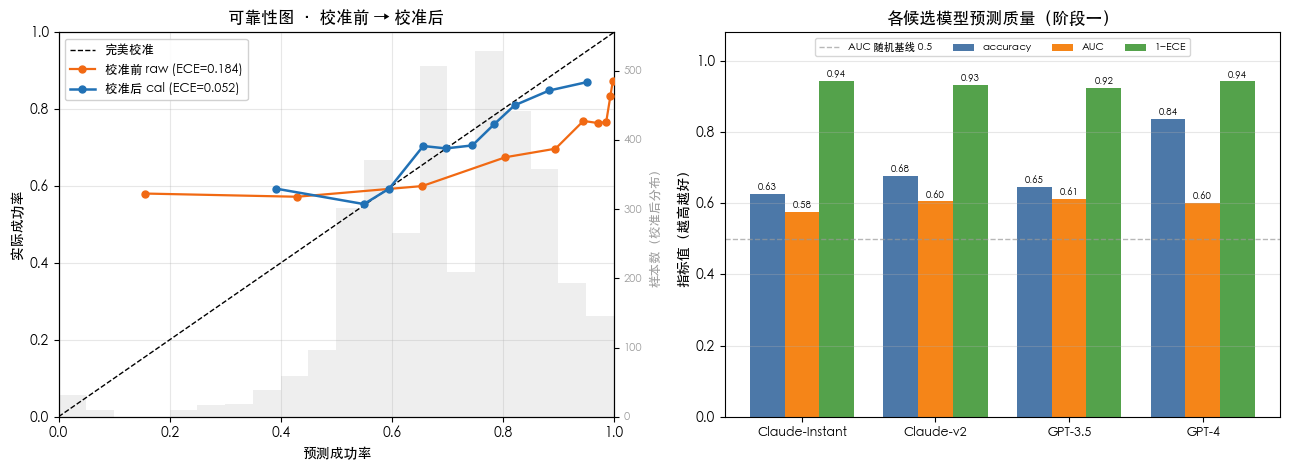

In [8]:
# 阶段一 · 1.3  可靠性图 + 指标对比
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.calibration import calibration_curve


def setup_chinese_font() -> str | None:
    """macOS/Windows 常见中文字体; 找不到则回退英文标签。"""
    candidates = [
        "PingFang SC",
        "Heiti SC",
        "STHeiti",
        "Arial Unicode MS",
        "SimHei",
        "Microsoft YaHei",
    ]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in candidates:
        if name in available:
            plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
            plt.rcParams["axes.unicode_minus"] = False
            return name
    plt.rcParams["axes.unicode_minus"] = False
    return None


_font = setup_chinese_font()
if _font:
    print(f"matplotlib 中文字体: {_font}")
else:
    print("未找到中文字体, 图表标签可能显示为方框")

def _overall_ece(y_true, p, n_bins: int = 10) -> float:
    """按分位数分箱的整体 ECE，和可靠性曲线口径一致。"""
    p = np.asarray(p, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    edges = np.unique(np.quantile(p, np.linspace(0, 1, n_bins + 1)))
    ece, n = 0.0, len(p)
    for i in range(len(edges) - 1):
        lo, hi = edges[i], edges[i + 1]
        mask = (p >= lo) & (p <= hi) if i == len(edges) - 2 else (p >= lo) & (p < hi)
        if mask.sum():
            ece += abs(y_true[mask].mean() - p[mask].mean()) * mask.sum() / n
    return ece


y_true = pred_df["y_true"].to_numpy(dtype=float)
p_cal = pred_df["p_success"].to_numpy(dtype=float)
has_raw = "p_success_raw" in pred_df.columns
p_raw = pred_df["p_success_raw"].to_numpy(dtype=float) if has_raw else None
ece_cal = _overall_ece(y_true, p_cal)
ece_raw = _overall_ece(y_true, p_raw) if has_raw else None

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# ── 左：可靠性图（校准前 → 校准后）────────────────────────────
ax0 = axes[0]
# 背景：预测概率分布（说明各分箱的样本密度，避免"点很少"的误解）
axb = ax0.twinx()
axb.hist(p_cal, bins=20, range=(0, 1), color="#cfcfcf", alpha=0.35, zorder=0)
axb.set_ylabel("样本数（校准后分布）", color="#9e9e9e", fontsize=9)
axb.tick_params(axis="y", labelcolor="#9e9e9e", labelsize=8)
ax0.set_zorder(axb.get_zorder() + 1)
ax0.patch.set_visible(False)

ax0.plot([0, 1], [0, 1], "k--", linewidth=1.0, label="完美校准", zorder=2)
if has_raw:
    fr_raw, mp_raw = calibration_curve(y_true, p_raw, n_bins=10, strategy="quantile")
    ax0.plot(mp_raw, fr_raw, "o-", color="#f16913", linewidth=1.6, markersize=5,
             label=f"校准前 raw (ECE={ece_raw:.3f})", zorder=3)
fr_cal, mp_cal = calibration_curve(y_true, p_cal, n_bins=10, strategy="quantile")
ax0.plot(mp_cal, fr_cal, "o-", color="#2171b5", linewidth=1.8, markersize=5,
         label=f"校准后 cal (ECE={ece_cal:.3f})", zorder=4)
ax0.set_xlim(0, 1)
ax0.set_ylim(0, 1)
ax0.set_xlabel("预测成功率")
ax0.set_ylabel("实际成功率")
title0 = "可靠性图 · 校准前 → 校准后" if has_raw else "可靠性图（校准后）"
ax0.set_title(title0)
ax0.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax0.grid(alpha=0.3)

# ── 右：各候选模型预测质量 ────────────────────────────────
ax1 = axes[1]
m = metrics_df[metrics_df["model"] != "__overall__"].copy()
name_map = {
    "gpt-4-1106-preview": "GPT-4",
    "gpt-3.5-turbo-1106": "GPT-3.5",
    "claude-v2": "Claude-v2",
    "claude-instant-v1": "Claude-Instant",
}
labels = [name_map.get(s, s.split("/")[-1][:12]) for s in m["model"]]
x = np.arange(len(m))
w = 0.26
bars = [
    ax1.bar(x - w, m["accuracy"], w, label="accuracy", color="#4c78a8"),
    ax1.bar(x, m["auc"], w, label="AUC", color="#f58518"),
    ax1.bar(x + w, 1 - m["ece"], w, label="1−ECE", color="#54a24b"),
]
ax1.axhline(0.5, color="#999999", linestyle="--", linewidth=1.0, alpha=0.7,
            label="AUC 随机基线 0.5")
for group in bars:
    for b in group:
        ax1.annotate(f"{b.get_height():.2f}", (b.get_x() + b.get_width() / 2, b.get_height()),
                     textcoords="offset points", xytext=(0, 2), ha="center", fontsize=7)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_ylim(0, 1.08)
ax1.set_ylabel("指标值（越高越好）")
ax1.set_title("各候选模型预测质量（阶段一）")
ax1.legend(fontsize=7.5, ncol=4, loc="upper center")
ax1.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()



### 阶段一 · 1.3b 中文特征重要度（诊断用）

全量 fit XGB 聚合 `feature_importances_`，**非回测指标**；embedding 384 维合并为一桶，结构特征逐项中文名。

**据此造高阶交互的思路**（下一轮特征工程）：
- `字符数 × 任务族_数值推理`：长文本数学题 vs 短题
- `数字个数 × 任务族_数值推理`：含多数字的推理题
- `选项个数(ABCD) × 任务族_选择题`：多选 vs 单选形态
- `是否含代码 × 任务族_代码`：代码题信号强化
- `CJK字符比例 × 是否中文`：中文文化类任务

2026-07-06 15:30:15.936 | INFO     | model.ml_seperate:encode_frozen:376 - 特征缓存命中: /Users/sihanpeng/Desktop/python/ai project/ai_project_myles/转型agent/Route Alpha/data/emb_cache.npz


,特征,重要度,备注,用途
0,语义embedding(384维)合计,0.966450,诊断用聚合桶，非单维解释,诊断（全量fit，非回测）
1,任务族_中文文化,0.008553,结构特征,诊断（全量fit，非回测）
2,任务族_选择题,0.008112,结构特征,诊断（全量fit，非回测）
3,大写字母比例,0.005851,结构特征,诊断（全量fit，非回测）
4,词数,0.003340,结构特征,诊断（全量fit，非回测）
5,数字个数,0.003324,结构特征,诊断（全量fit，非回测）
6,平均词长,0.002335,结构特征,诊断（全量fit，非回测）
7,字符数,0.001521,结构特征,诊断（全量fit，非回测）
8,数字个数x数值推理,0.000450,结构特征,诊断（全量fit，非回测）
9,问号个数,0.000064,结构特征,诊断（全量fit，非回测）


图已保存: /Users/sihanpeng/Desktop/python/ai project/ai_project_myles/转型agent/Route Alpha/docs/feature_importance.png


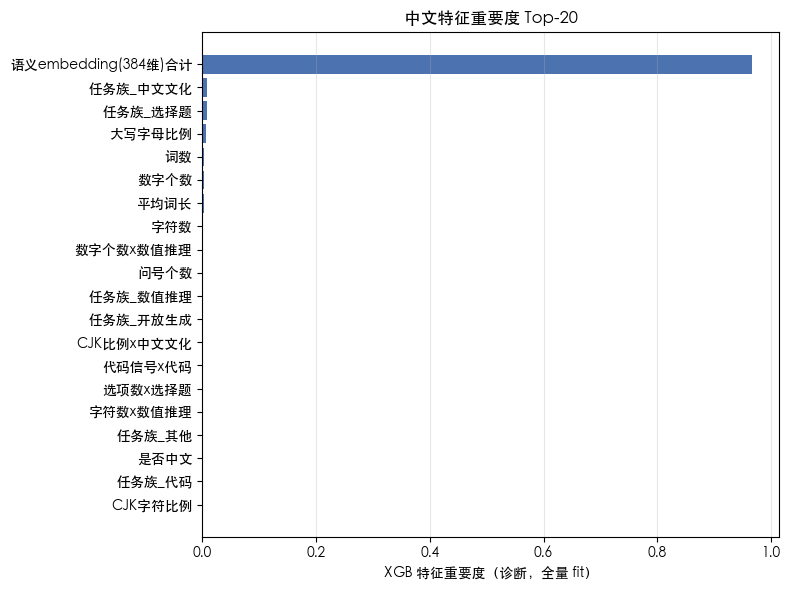

In [9]:
# 阶段一 · 1.3b  中文特征重要度条形图（诊断，非回测）
from pathlib import Path

import matplotlib.pyplot as plt

if "setup_chinese_font" not in globals():
    from matplotlib import font_manager

    def setup_chinese_font() -> str | None:
        for name in ["PingFang SC", "Heiti SC", "STHeiti", "Arial Unicode MS", "SimHei"]:
            if name in {f.name for f in font_manager.fontManager.ttflist}:
                plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
                plt.rcParams["axes.unicode_minus"] = False
                return name
        plt.rcParams["axes.unicode_minus"] = False
        return None

setup_chinese_font()

imp_df = ml.feature_importance_report(cfg, feat, data, top_k=20)
display(imp_df)

fig, ax = plt.subplots(figsize=(8, 6))
plot_df = imp_df.sort_values("重要度", ascending=True)
ax.barh(plot_df["特征"], plot_df["重要度"], color="#4c72b0")
ax.set_xlabel("XGB 特征重要度（诊断，全量 fit）")
ax.set_title("中文特征重要度 Top-20")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()

out_imp = Path("docs/feature_importance.png")
out_imp.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_imp, dpi=150, bbox_inches="tight")
print(f"图已保存: {out_imp.resolve()}")
plt.show()

## 阶段二 · MILP 预算约束路由

用阶段一产出的 `p_success`（默认 **Isotonic 校准后**）做路由决策；对比 baseline 与 Pareto 前沿。

In [10]:
# MILP 预算约束路由 vs 四条 baseline
from model import milp as mp
importlib.reload(mp)

budget_per_query = cfg["milp"]["budget_per_query"]
table = mp.compare(pred_df, budget_per_query=budget_per_query)
table

2026-07-06 15:30:20.753 | INFO     | model.milp:solve_routing:131 - MILP: Q=900 query, M=4 模型, 预算=1.80000


Set parameter Username
Set parameter LicenseID to value 2712532
Academic license - for non-commercial use only - expires 2026-09-24


2026-07-06 15:30:20.808 | INFO     | model.milp:solve_routing:172 - MILP optimal: 期望成功 771.0, 真实成功率 0.810, 花费 1.79919/1.80000


,策略,真实成功率,期望成功率,总成本,状态
0,oracle,0.9267,0.6720,0.45122,ok
1,always_expensive,0.8511,0.8330,3.02855,ok
2,milp(预算=0.002/条),0.8100,0.8567,1.79919,optimal
3,random,0.7200,0.7088,1.47353,ok
4,always_cheap,0.6467,0.6501,0.19042,ok


## 阶段二 · 2.2 Pareto 前沿（成本 vs 成功率）

- **横轴**：平均成本 / query（越低越省）
- **纵轴**：真实成功率（越高越好）
- **理想方向**：左上角（低成本 + 高成功率）
- **MILP 曲线**：扫不同预算，看路由策略如何从右下向左上移动
- **散点**：always-cheap / always-expensive / random / oracle 四条 baseline

In [11]:
# 2.3b 已合并到下一 cell（避免重复出图）
pass


## 阶段二 · 2.3 迭代追踪：每次优化记一个点，看它逼近 oracle 天花板

**核心思路**：固定预算（`budget_per_query`）下，每个预测器版本在 Pareto / 本表中是**一行记录**。

> **注意**：`record_iteration` 是**实验日志**，不是特征开关。开关在 `config.yaml` → `features.*`；改 config 后须**重跑 `rolling_backtest`**，再跑下方 cell 写入 csv。

- `oracle 天花板`：数据硬上限（用 `y_true` 作弊），**再准的预测也超不过**。
- `gap = oracle − MILP`：几乎全部来自预测误差。
- 记录持久化在 `docs/iteration_log.csv`；**同名版本覆盖**，不同 version 名累积多行供 2.3b 画图。

In [12]:
# 阶段二 · 2.3  迭代记录：把当前 pred_df 的成绩记一行（不是特征开关！）
# 特征开关在 config.yaml → features.*；改 config 后须重跑 rolling_backtest 再调本 cell
from pathlib import Path

import pandas as pd
from model import milp as mp

ITER_LOG = Path("docs/iteration_log.csv")


def feature_note(cfg: dict) -> str:
    """从 config 自动生成备注，避免 version/note 与真实开关不一致。"""
    fc = cfg.get("features", {})
    parts = ["bge384"]
    if fc.get("use_structural", True):
        parts.append("24维结构")
    if fc.get("use_target_encoding", False):
        parts.append(f"TE(alpha={fc.get('target_encoding_alpha', 10)})")
    if fc.get("use_cross_difficulty", False):
        parts.append("cross+mglobal")
    return " + ".join(parts)


def record_iteration(version: str, pred_df, cfg, note: str = "", prob_col: str = "p_success") -> pd.DataFrame:
    """记录当前版本在固定预算下的成绩，持久化到 csv（同名版本覆盖）。"""
    budget = cfg["milp"]["budget_per_query"]
    Q = pred_df["sample_id"].nunique()
    metrics = ml.compute_metrics(pred_df, prob_col=prob_col)
    ov = metrics[metrics["model"] == "__overall__"].iloc[0]
    oracle_s = mp.baselines(pred_df, prob_col=prob_col)["oracle"].realized_success_rate
    milp = mp.solve_routing(pred_df, budget_per_query=budget, prob_col=prob_col)
    row = {
        "版本": version,
        "AUC": round(float(ov["auc"]), 4),
        "ECE": round(float(ov["ece"]), 4),
        "MILP成功率": round(milp.realized_success_rate, 4),
        "成本/q": round(milp.total_cost / Q, 5),
        "oracle天花板": round(oracle_s, 4),
        "gap": round(oracle_s - milp.realized_success_rate, 4),
        "预算/q": budget,
        "备注": note or feature_note(cfg),
    }
    if ITER_LOG.exists():
        log = pd.read_csv(ITER_LOG, encoding="utf-8")
        log = log[log["版本"] != version]
        log = pd.concat([log, pd.DataFrame([row])], ignore_index=True)
    else:
        ITER_LOG.parent.mkdir(parents=True, exist_ok=True)
        log = pd.DataFrame([row])
    log.to_csv(ITER_LOG, index=False, encoding="utf-8")
    return log


# 换实验版本：改 config → 重跑 rolling_backtest → 改 version 字符串 → 跑本 cell
# 同名 version 会覆盖旧行；不同 version 会累积多行供 2.3b 画图
iter_log = record_iteration(
    "v3_TE+cross+mglobal",
    pred_df,
    cfg,
    # note 留空则自动从 config 生成
)
iter_log

2026-07-06 15:30:20.837 | INFO     | model.milp:solve_routing:131 - MILP: Q=900 query, M=4 模型, 预算=1.80000
2026-07-06 15:30:20.874 | INFO     | model.milp:solve_routing:172 - MILP optimal: 期望成功 771.0, 真实成功率 0.810, 花费 1.79919/1.80000


,版本,AUC,ECE,MILP成功率,成本/q,oracle天花板,gap,预算/q,备注
0,v1_emb+结构+交互,0.6462,0.0586,0.8033,0.002,0.9267,0.1233,0.002,bge384 + 24维中文结构/交互特征
1,v0_baseline,0.5664,0.0565,0.8022,0.002,0.9267,0.1244,0.002,bge384 + 24维结构 + 无TE
2,v2_TE_only,0.6371,0.0542,0.7989,0.002,0.9267,0.1278,0.002,bge384 + 24维结构 + TE(alpha=10.0)
3,v0_baseline,0.5664,0.0565,0.7622,0.001,0.9267,0.1644,0.001,demo预算(紧预算下路由增益最明显)
4,v2_TE_only,0.6371,0.0542,0.7689,0.001,0.9267,0.1578,0.001,demo预算(紧预算下路由增益最明显)
5,v3_TE+cross+mglobal,0.6429,0.0516,0.8100,0.002,0.9267,0.1167,0.002,bge384 + 24维结构 + TE(alpha=20.0)


2026-07-06 15:35:50.303 | INFO     | model.milp:solve_routing:131 - MILP: Q=900 query, M=4 模型, 预算=0.90000
2026-07-06 15:35:50.345 | INFO     | model.milp:solve_routing:172 - MILP optimal: 期望成功 733.5, 真实成功率 0.762, 花费 0.89997/0.90000
2026-07-06 15:35:50.352 | INFO     | model.milp:solve_routing:131 - MILP: Q=900 query, M=4 模型, 预算=0.90000
2026-07-06 15:35:50.389 | INFO     | model.milp:solve_routing:172 - MILP optimal: 期望成功 747.9, 真实成功率 0.769, 花费 0.89964/0.90000
2026-07-06 15:35:50.395 | INFO     | model.milp:solve_routing:131 - MILP: Q=900 query, M=4 模型, 预算=0.90000
2026-07-06 15:35:50.432 | INFO     | model.milp:solve_routing:172 - MILP optimal: 期望成功 749.1, 真实成功率 0.777, 花费 0.89911/0.90000


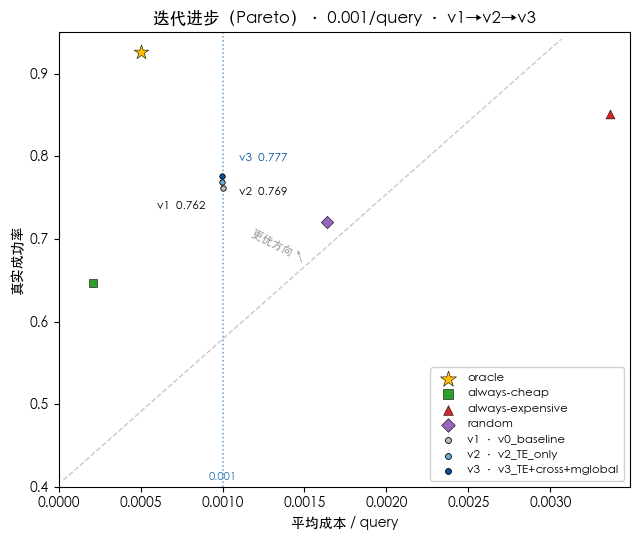

In [16]:
# 阶段二 · 2.3b  迭代进步图（极简 · v1→v2→v3 @ 0.001/query）
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from model import milp as mp

if "setup_chinese_font" in globals():
    setup_chinese_font()

DEMO_BUDGET = 0.0010
VERSIONS = [
    ("v1", Path("data/predictions_v0.parquet"), "#bdbdbd", "v1 · v0_baseline"),
    ("v2", Path("data/predictions_v2.parquet"), "#6baed6", "v2 · v2_TE_only"),
    ("v3", Path("data/predictions.parquet"), "#08519c", "v3 · v3_TE+cross+mglobal"),
]

ref = pd.read_parquet(VERSIONS[-1][1])
Q = ref["sample_id"].nunique()
bs = mp.baselines(ref)

def cpq(r):
    return r.total_cost / Q, r.realized_success_rate

fig, ax = plt.subplots(figsize=(6.5, 5.5))

# baseline：oracle / always-cheap / always-expensive / random
for key, c, m, s, lab in [
    ("oracle", "#ffbf00", "*", 120, "oracle"),
    ("always_cheap", "#2ca02c", "s", 40, "always-cheap"),
    ("always_expensive", "#d62728", "^", 40, "always-expensive"),
    ("random", "#9467bd", "D", 40, "random"),
]:
    cx, sy = cpq(bs[key])
    ax.scatter(cx, sy, c=c, marker=m, s=s, label=lab, edgecolors="k", linewidths=0.4, zorder=5)

# v1 / v2 / v3：同预算、同成本竖排；SR 值直接写在点旁（错开避免叠字）
traj_x, traj_y = [], []
MARKER_S = {"v1": 15, "v2": 15, "v3": 15}
LABEL_OFFSET = {
    "v1": (-12, -13),   # 左下
    "v2": (12, -7),     # 右略下
    "v3": (12, 13),     # 右上
}
for short, path, color, legend_lab in VERSIONS:
    pred = pd.read_parquet(path)
    milp = mp.solve_routing(pred, budget_per_query=DEMO_BUDGET)
    cx, sy = cpq(milp)
    traj_x.append(cx)
    traj_y.append(sy)
    ax.scatter(
        cx, sy,
        s=MARKER_S[short],
        c=color,
        label=legend_lab,
        edgecolors="k",
        linewidths=0.6,
        zorder=8,
    )
    ox, oy = LABEL_OFFSET[short]
    ax.annotate(
        f"{short}  {sy:.3f}",
        (cx, sy),
        xytext=(ox, oy),
        textcoords="offset points",
        fontsize=8.5,
        color=color if short == "v3" else "black",
        fontweight="bold" if short == "v3" else "normal",
        ha="right" if short == "v1" else "left",
        va="center",
    )

x_hi = cpq(bs["always_expensive"])[0] + 0.00012
ax.set_xlim(0, x_hi)
ax.set_ylim(0.4, 0.95)

# v1–v3 固定预算：竖虚线 + 成本数字
ax.axvline(DEMO_BUDGET, color="#2171b5", linestyle=":", linewidth=1.1, alpha=0.7, zorder=1)
y_lo = ax.get_ylim()[0]
ax.text(
    DEMO_BUDGET,
    y_lo + 0.006,
    f"{DEMO_BUDGET:.3f}",
    fontsize=8,
    ha="center",
    va="bottom",
    color="#2171b5",
)

# 迭代轨迹：同成本下竖直虚线 v1→v2→v3
ax.plot(traj_x, traj_y, "--", color="#2171b5", linewidth=1.4, alpha=0.75, zorder=6)

# 参考斜虚线：左下→右上（背景示意）；箭头单独指左上 = 低成本+高成功率
x_lo, x_hi_plot = ax.get_xlim()
y_lo, y_hi_plot = ax.get_ylim()
ax.plot(
    [x_lo + 0.00003, x_hi_plot * 0.88],
    [y_lo + 0.008, y_hi_plot - 0.008],
    linestyle="--",
    color="#888888",
    linewidth=1.0,
    alpha=0.45,
    zorder=0,
)
ax.text(
    x_lo + (x_hi_plot - x_lo) * 0.38,
    y_lo + (y_hi_plot - y_lo) * 0.52,
    "更优方向 ↖",
    fontsize=8,
    color="#999999",
    rotation=-27,
    rotation_mode="anchor",
    ha="center",
    va="bottom",
)

ax.set_xlabel("平均成本 / query")
ax.set_ylabel("真实成功率")
ax.set_title(f"迭代进步（Pareto）· {DEMO_BUDGET}/query · v1→v2→v3")
ax.legend(
    loc="lower right",
    fontsize=8.5,
    markerscale=1.1,
    labelspacing=0.45,
    handletextpad=0.6,
    borderpad=0.5,
    framealpha=0.9,
)
plt.tight_layout()
plt.show()

## 阶段二 · 2.4 失败模式归因（badcase）

对 MILP 路由**失败**的 query 逐条打标签，回答面试常问：**「质量掉了，锅在预测、校准、预算还是任务本身？」**

| 标签 | 含义 |
|------|------|
| `prediction_error` | 预测排序错，没选到更可能成功的模型 |
| `calibration_error` | 概率刻度误导（对失败模型过度自信） |
| `budget_binding` | 预算太紧，被迫选便宜模型 |
| `task_hard` | oracle 也失败，任务本身难 |
| `label_noise` | 边界/存疑样本 |

逻辑见 `eval/failure_analysis.py`，报告写入 `eval/failure_report.md`。

In [ ]:
# 阶段二 · 2.4  失败样本归因
import sys
from pathlib import Path

sys.path.insert(0, str(Path(".").resolve()))
from eval.failure_analysis import analyze_routing_failures, plot_failure_summary, write_report

if "setup_chinese_font" in globals():
    setup_chinese_font()

budget_attr = cfg["milp"]["budget_per_query"]
badcase_df, summary_df, attr_metrics = analyze_routing_failures(
    pred_df,
    budget_per_query=budget_attr,
    max_rows=15,
)
attr_metrics["budget_per_query"] = budget_attr

display(summary_df)
display(badcase_df)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
plot_failure_summary(summary_df, ax=ax)
plt.tight_layout()
plt.show()

write_report(badcase_df, summary_df, attr_metrics, Path("eval/failure_report.md"))
print("指标:", attr_metrics)
print("报告已写入 eval/failure_report.md")